## MERFISH mouse liver: Notebook to determine ROIs for overlapping cells in 3d spot-based transcriptomics data

This notebook contains a prototype implementation of an ovrl.py analysis script for vizgen's MERFISH liver showcase data set. It runs tha basic ovrlpy analysis pipeline and stores the result;

#### Imports:

In [1]:
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

import ovrlpy

In [2]:
centimeter = 1 / 2.54  # conversion from inch, for plotting

font = {"family": "sans-serif", "weight": "normal", "size": 6}

matplotlib.rc("font", **font)

In [3]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True, parents=True)

#### Parameter definition:

In [12]:
n_sample = 1
n_slice = 1

merfish_dir = Path(
    f"/dh-projects/ag-ishaque/raw_data/vizgen-merfish/vz-liver-showcase/Liver{n_sample}Slice{n_slice}"
)

coordinate_path = merfish_dir / "detected_transcripts.csv"

signature_file = (
    Path("/dh-projects/ag-ishaque/analysis/tiesmeys/data/ovrlpy/signatures")
    / "signatures_liver_atlas.csv"
)

In [13]:
signatures = pd.read_csv(signature_file, index_col=0).T

In [5]:
coordinate_df = ovrlpy.io.read_MERFISH(coordinate_path)

In [6]:
# subset coordinates
x_lims = [2000, 9000]
y_lims = [1000, 8000]

coordinate_df = coordinate_df.filter(
    pl.col("x") > x_lims[0],
    pl.col("x") < x_lims[1],
    pl.col("y") > y_lims[0],
    pl.col("y") < y_lims[1],
).with_columns(
    pl.col("x") - x_lims[0],
    pl.col("y") - y_lims[0],
)

In [20]:
liver = ovrlpy.Ovrlp(
    coordinate_df,
    n_components=15,
    min_distance=6,
    KDE_bandwidth=1.7,
    random_state=42,
    n_workers=16,
)
liver.analyse()

Running vertical adjustment
Creating gene expression embeddings for visualization
determining pseudocells
found 117646 pseudocells
sampling expression:


100%|██████████| 81/81 [03:04<00:00,  2.28s/it]


Modeling 15 pseudo-celltype clusters;
Creating signal integrity map


100%|██████████| 196/196 [04:34<00:00,  1.40s/it]


In [21]:
signal_integrity = liver.integrity_map
signal_strength = liver.signal_map

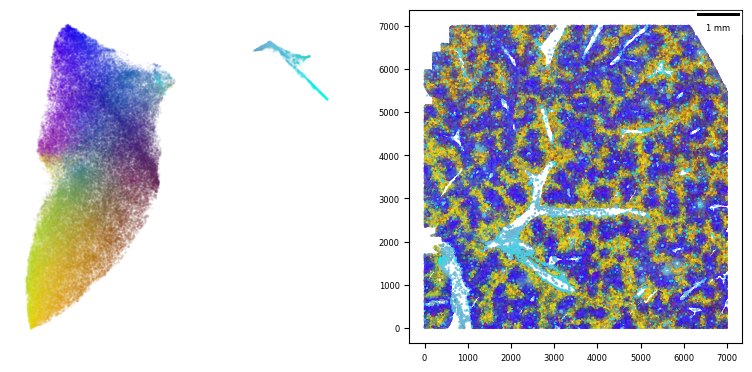

In [22]:
fig = ovrlpy.plot_pseudocells(liver, figsize=(24 * centimeter, 12 * centimeter))

fig.savefig(out_dir / "vizgen-liver.pdf", dpi=600)
fig.savefig(out_dir / "vizgen-liver.svg", dpi=600)

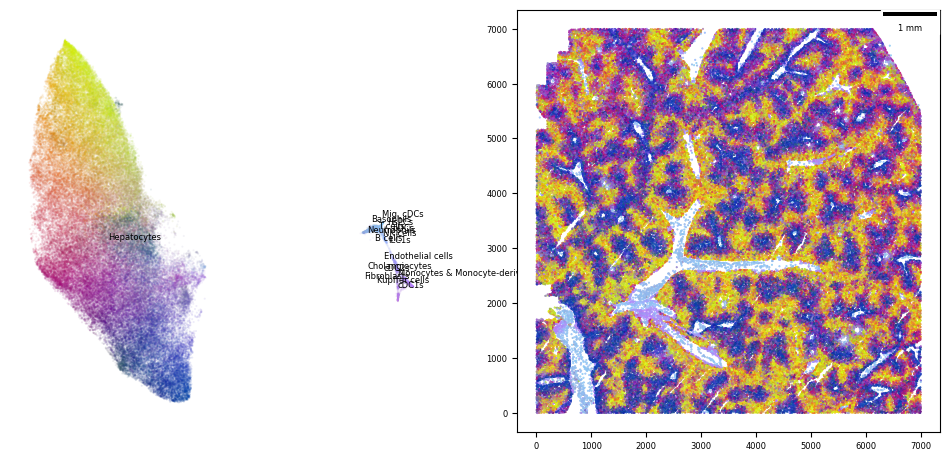

In [12]:
liver.fit_signatures(signatures)

fig = ovrlpy.plot_pseudocells(liver)
fig.axes[1].set(xticks=[], yticks=[])

fig.savefig(out_dir / "liver-fit.pdf", dpi=600)
fig.savefig(out_dir / "liver-fit.svg", dpi=600)

In [13]:
import pickle

with open("merscope_liver.pickle", "wb") as file:
    pickle.dump(liver, file)

In [4]:
import pickle

with open("merscope_liver.pickle", "rb") as file:
    liver = pickle.load(file)

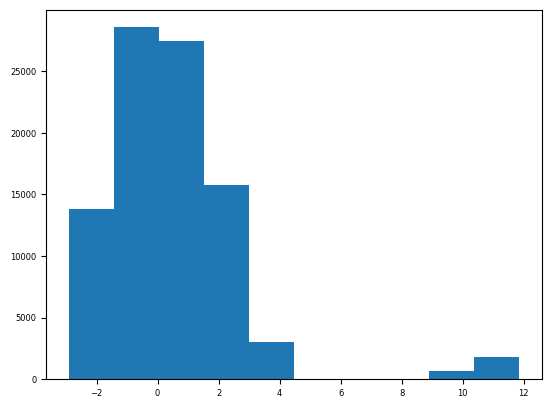

In [5]:
_ = plt.hist(liver.pseudocells.obsm["2D_UMAP"][:, 0])

In [8]:
umap_delimiter = 6  # values with embedding.x < umap_delimiter are stromal
stromal_mask = liver.pseudocells.obsm["2D_UMAP"][:, 0] > umap_delimiter

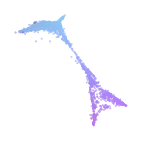

In [9]:
fig, ax = plt.subplots(figsize=(4 * centimeter, 4 * centimeter))
ax.scatter(
    liver.pseudocells.obsm["2D_UMAP"][stromal_mask, 0],
    liver.pseudocells.obsm["2D_UMAP"][stromal_mask, 1],
    c=liver.pseudocells.obsm["RGB"][stromal_mask],
    s=0.1,
    # rasterized=True,
)
ax.axis("off")

fig.savefig(out_dir / "stromal_embedding_general_colors.svg", dpi=600)

In [14]:
from copy import deepcopy

liver_stromal = deepcopy(liver)

liver_stromal.pca.set_params(n_components=12)

liver_stromal.fit_pseudocells(liver.pseudocells[stromal_mask, :].copy())
liver_stromal.fit_signatures(signatures)

Modeling 12 pseudo-celltype clusters;


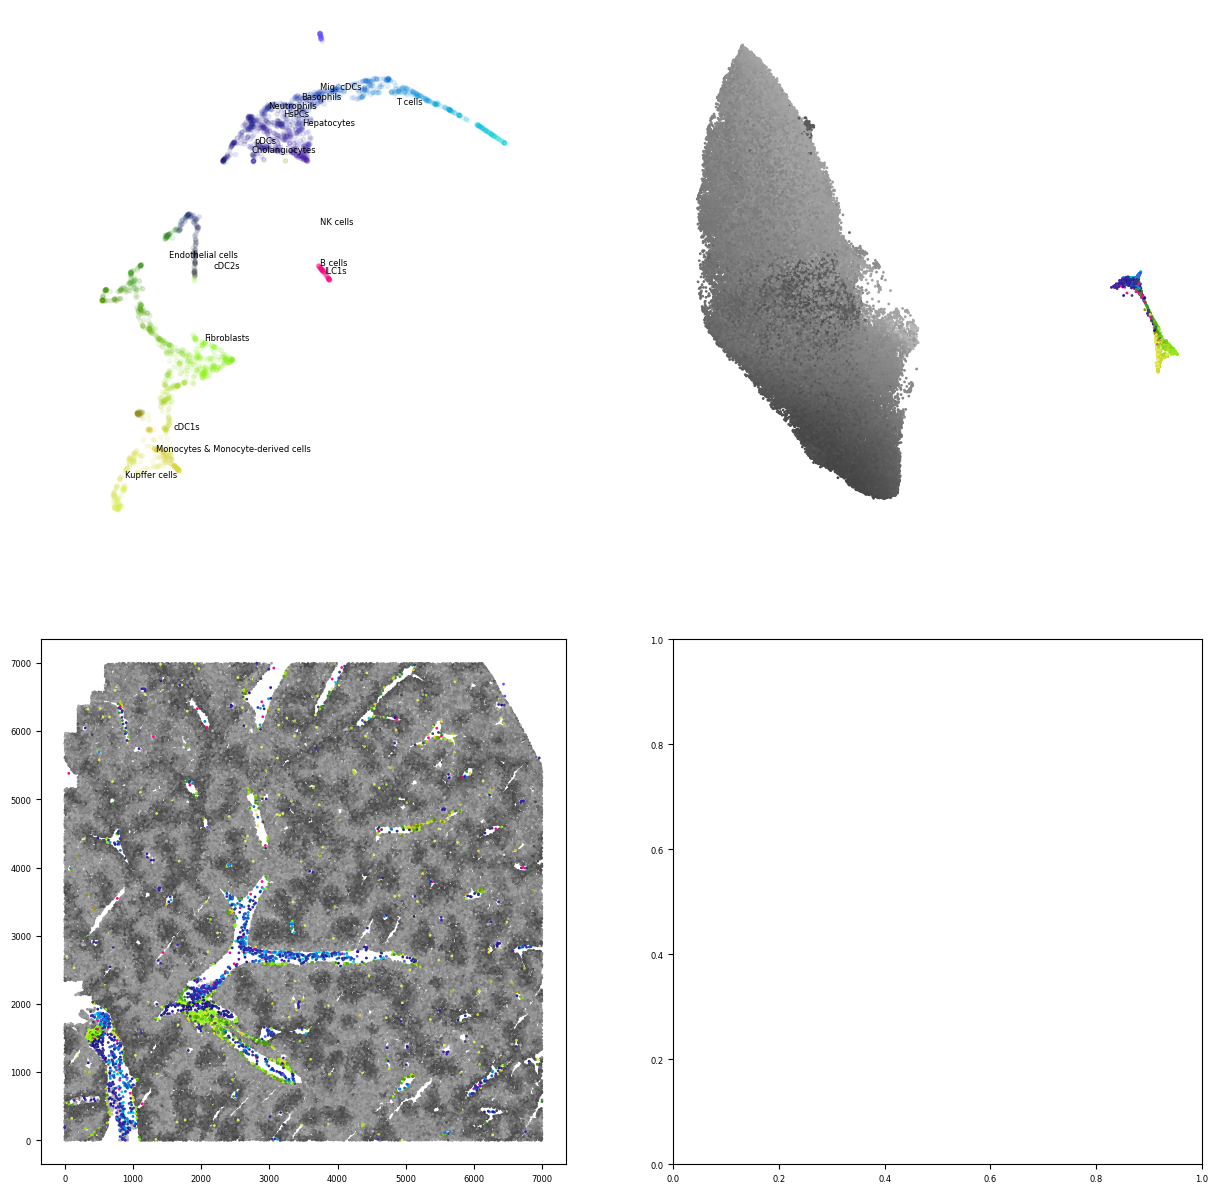

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
plt.subplot(222)
rgb_array = liver.pseudocells.obsm["RGB"].copy()
rgb_array[:] = rgb_array.mean(1, keepdims=True)
rgb_array[stromal_mask] = liver_stromal.pseudocells.obsm["RGB"].copy()

ovrlpy.plot_umap(liver_stromal, ax=axs[0, 0])

axs[0, 1].scatter(
    liver.pseudocells.obsm["2D_UMAP"][:, 0],
    liver.pseudocells.obsm["2D_UMAP"][:, 1],
    s=1,
    c=rgb_array,
    # rasterized=True,
)
axs[0, 1].set(aspect="equal")
axs[0, 1].axis("off")

axs[1, 0].scatter(
    liver.pseudocells.obsm["spatial"][:, 0],
    liver.pseudocells.obsm["spatial"][:, 1],
    s=1,
    c=rgb_array,
    # rasterized=True,
)
axs[1, 0].set(aspect="equal")

# axs[1, 1].scatter(
#     liver_stromal.pseudocells.obsm["spatial"][:, 0],
#     liver_stromal.pseudocells.obsm["spatial"][:, 1],
#     s=5,
#     c=liver_stromal.pseudocells.obsm["RGB"],
#     # rasterized=True,
# )
# axs[1, 1].set(aspect="equal")

plt.savefig("liver_stromal_umap.svg", dpi=600)

In [16]:
doublet_df = liver.detect_doublets(min_signal=3, integrity_sigma=2)

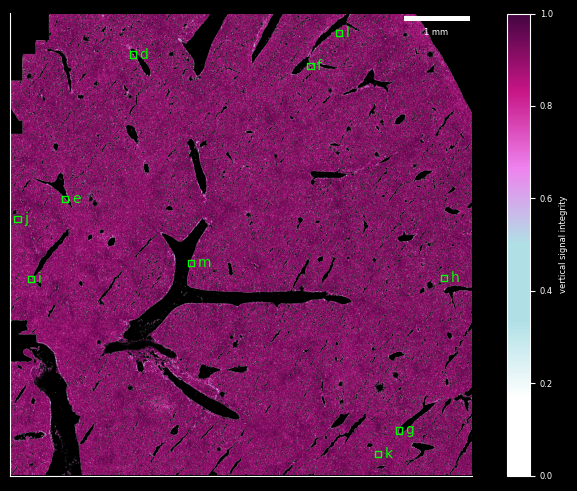

In [19]:
fig = ovrlpy.plot_signal_integrity(
    liver,
    signal_threshold=3,
    histogram=False,
    scalebar={"dx": 1, "units": "um", "frameon": False, "color": "w"},
)

fig.axes[0].set(xticks=[], yticks=[])

alphabet = "abcdefghijklmnopqrstuvwxyz"

for i in range(10):
    x, y = doublet_df["x", "y"].row(i)

    fig.axes[0].text(
        x + 100, y, alphabet[i + 3], color="lime", fontsize=10, va="center"
    )
    fig.axes[0].scatter(
        x, y, marker="s", s=20, edgecolors="lime", facecolors="None", lw=1
    )

fig.savefig("liver_integrity.svg", dpi=600)

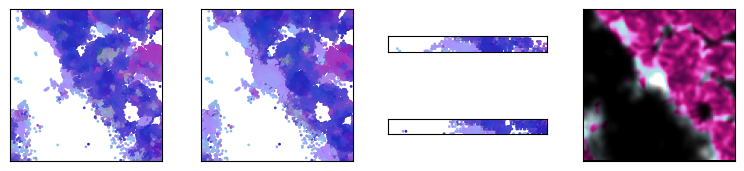

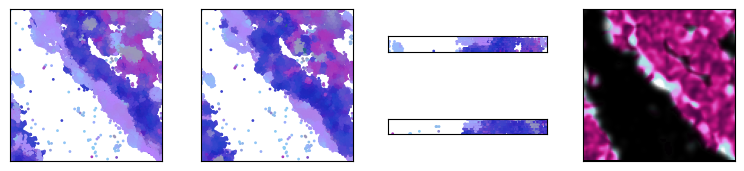

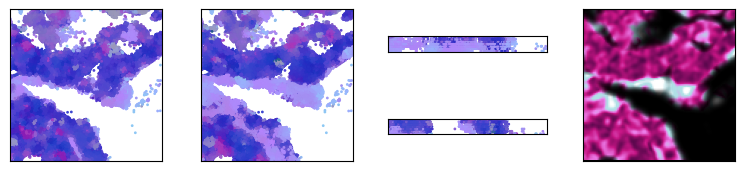

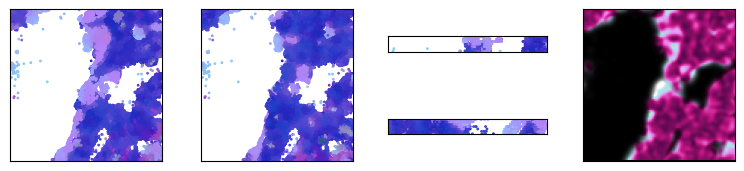

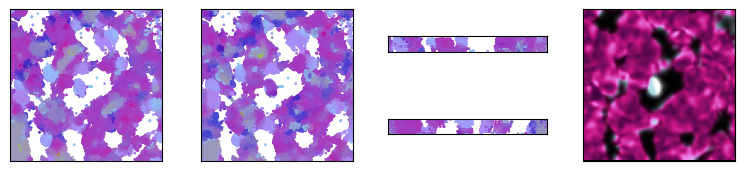

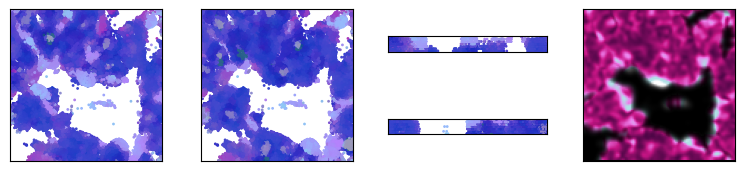

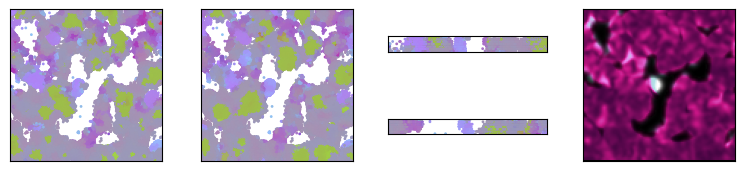

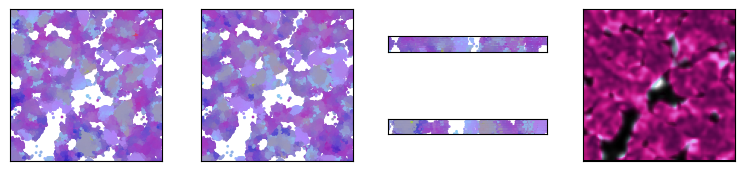

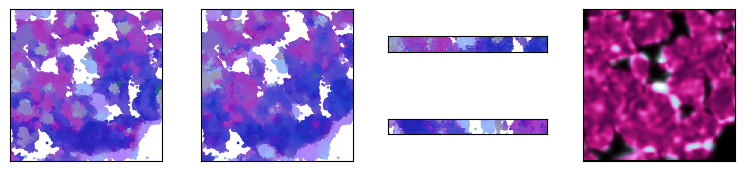

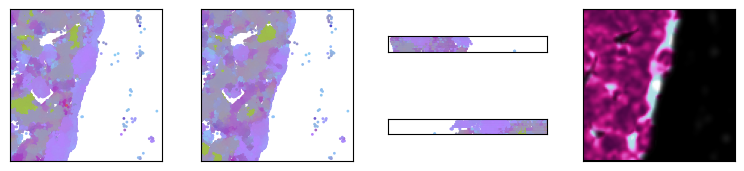

In [20]:
import sys

sys.path.append("..")

from utils import plot_doublet

doublet_dir = out_dir / "doublet-case-visualizations"
doublet_dir.mkdir(exist_ok=True, parents=True)


for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    fig = plot_doublet(liver, x, y)
    fig.savefig(doublet_dir / f"doublet_case_{i+1}.svg", dpi=600)

In [30]:
from utils import CM, plot_transcripts


def recolor_liver(ovrlp, transcripts, t):
    embedding, embedding_color = ovrlp.transform_transcripts(transcripts)
    stromal_mask = embedding[:, 0] > t
    embedding_color[:] = embedding_color.mean(axis=1)[:, None]

    return stromal_mask, embedding_color


def plot_doublet_recolor(
    ovrlp, ovrlp2, x, y, t, window_size=50, figsize=(24 * CM, 5 * CM)
):
    signal_integrity = ovrlp.integrity_map[
        int(y) - window_size : int(y) + window_size,
        int(x) - window_size : int(x) + window_size,
    ]

    signal_strength = ovrlp.signal_map[
        int(y) - window_size : int(y) + window_size,
        int(x) - window_size : int(x) + window_size,
    ]

    roi_transcripts = ovrlp.subset_transcripts(x, y, window_size=window_size).sort("z")

    mask, embedding_color = recolor_liver(ovrlp, roi_transcripts, t)

    _, embedding_color2 = ovrlp2.transform_transcripts(roi_transcripts.filter(mask))
    embedding_color[mask] = embedding_color2
    roi_transcripts = roi_transcripts.with_columns(RGB=embedding_color)

    return plot_transcripts(
        roi_transcripts, signal_integrity, signal_strength, x, y, window_size, figsize
    )

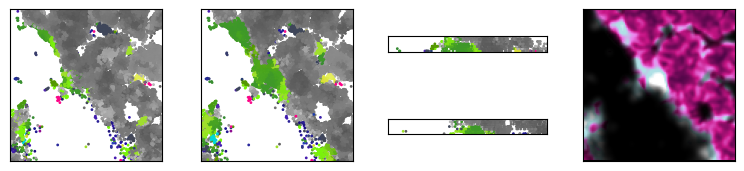

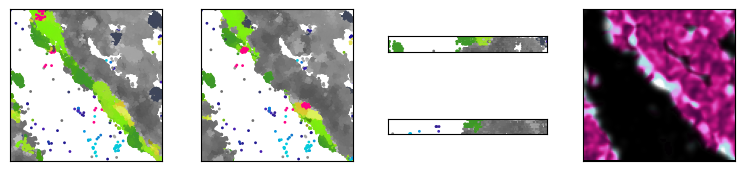

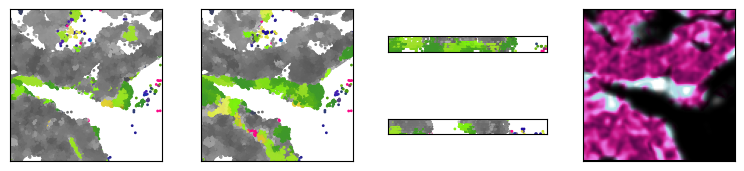

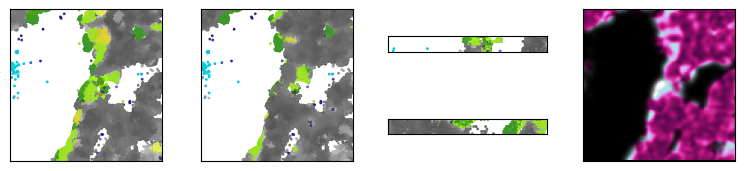

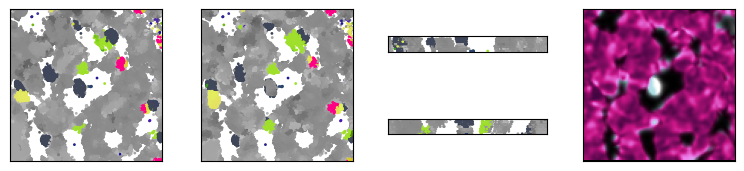

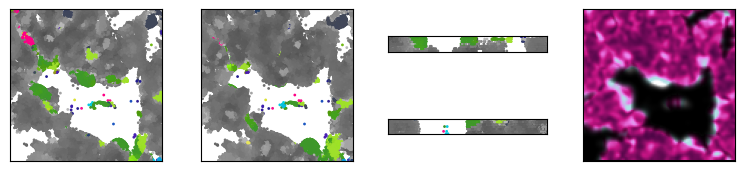

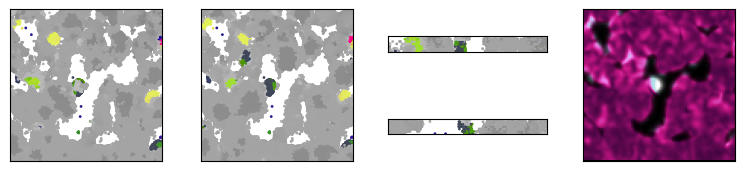

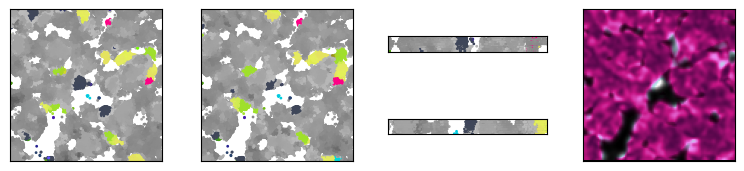

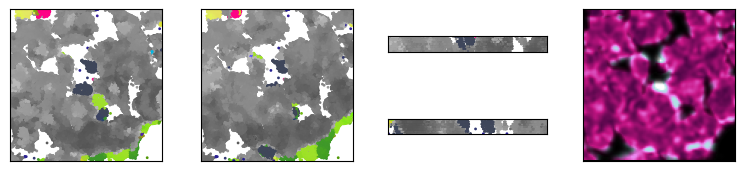

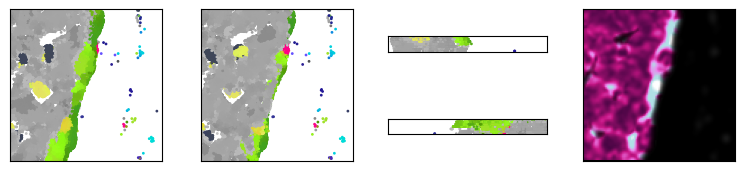

In [31]:
doublet_dir = out_dir / "doublet-case-visualizations_recolored"
doublet_dir.mkdir(exist_ok=True, parents=True)


for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    fig = plot_doublet_recolor(liver, liver_stromal, x, y, umap_delimiter)
    fig.savefig(doublet_dir / f"doublet_case_{i+1}.svg", dpi=600)